In [2]:
import sys
sys.path.append("..")
import importlib
import numpy as np
import src.black_scholes as bs
importlib.reload(bs)

S, K, T, r, sigma = 100, 100, 1, 0.05, 0.2

C = bs.bs_price(S, K, T, r, sigma, "call")
P = bs.bs_price(S, K, T, r, sigma, "put")
print(f"Call = {C:.4f}, Put = {P:.4f}")
print(f"Parité : C - P = {C - P:.4f} | S - K·e^(-rT) = {S - K*np.exp(-r*T):.4f}")

print("Delta call :", round(bs.bs_delta(S, K, T, r, sigma, "call"), 4))
print("Delta put  :", round(bs.bs_delta(S, K, T, r, sigma, "put"), 4))
print("Gamma      :", round(bs.bs_gamma(S, K, T, r, sigma), 4))
print("Vega       :", round(bs.bs_vega(S, K, T, r, sigma), 4))

Call = 10.4506, Put = 5.5735
Parité : C - P = 4.8771 | S - K·e^(-rT) = 4.8771
Delta call : 0.6368
Delta put  : -0.3632
Gamma      : 0.0188
Vega       : 37.524


N =       100 | prix MC = 7.8258 | erreur std = 1.0120
N =       300 | prix MC = 9.1860 | erreur std = 0.8223
N =     1,000 | prix MC = 9.9120 | erreur std = 0.4483
N =     3,000 | prix MC = 10.1665 | erreur std = 0.2645
N =    10,000 | prix MC = 10.3452 | erreur std = 0.1477
N =    30,000 | prix MC = 10.5826 | erreur std = 0.0860
N =   100,000 | prix MC = 10.4205 | erreur std = 0.0468
N =   300,000 | prix MC = 10.4553 | erreur std = 0.0270
N = 1,000,000 | prix MC = 10.4532 | erreur std = 0.0147


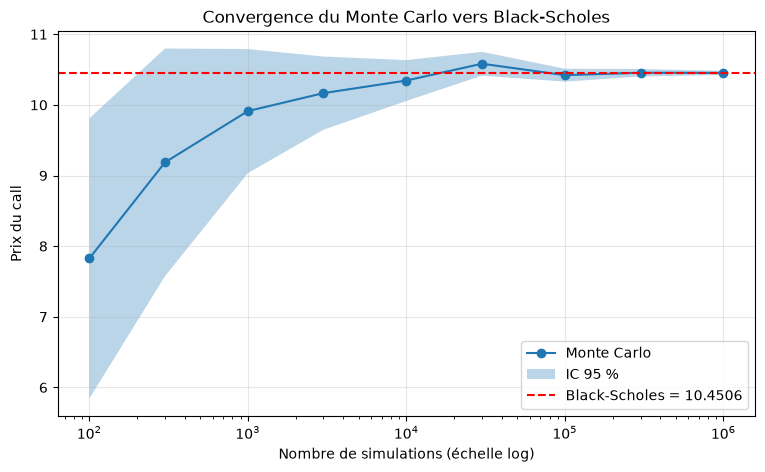

In [3]:
import matplotlib.pyplot as plt
import src.monte_carlo as mc
importlib.reload(mc)

C_bs = bs.bs_price(S, K, T, r, sigma, "call")
Ns = [100, 300, 1_000, 3_000, 10_000, 30_000, 100_000, 300_000, 1_000_000]
prices, errors = [], []

for N in Ns:
    p, se = mc.mc_price(S, K, T, r, sigma, "call", n_paths=N, seed=42)
    prices.append(p)
    errors.append(se)
    print(f"N = {N:>9,} | prix MC = {p:.4f} | erreur std = {se:.4f}")

prices, errors = np.array(prices), np.array(errors)

plt.figure(figsize=(9, 5))
plt.plot(Ns, prices, "o-", label="Monte Carlo")
plt.fill_between(Ns, prices - 1.96 * errors, prices + 1.96 * errors, alpha=0.3, label="IC 95 %")
plt.axhline(C_bs, color="red", linestyle="--", label=f"Black-Scholes = {C_bs:.4f}")
plt.xscale("log")
plt.xlabel("Nombre de simulations (échelle log)")
plt.ylabel("Prix du call")
plt.title("Convergence du Monte Carlo vers Black-Scholes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [5]:
import time
import src.finite_differences as fd
importlib.reload(fd)

# Convergence : on raffine la grille
print("Convergence des différences finies (call)")
for M in [25, 50, 100, 200, 400]:
    p = fd.fd_price(S, K, T, r, sigma, "call", M=M, N=M)
    print(f"Grille {M:>3}x{M:<3} | prix = {p:.6f} | erreur = {abs(p - C_bs):.2e}")

# Comparaison finale des 3 méthodes
print("\nComparaison des 3 méthodes (call)")
t0 = time.perf_counter(); p_bs = bs.bs_price(S, K, T, r, sigma, "call"); t_bs = time.perf_counter() - t0
t0 = time.perf_counter(); p_mc, se = mc.mc_price(S, K, T, r, sigma, "call", n_paths=1_000_000, seed=42); t_mc = time.perf_counter() - t0
t0 = time.perf_counter(); p_fd = fd.fd_price(S, K, T, r, sigma, "call", M=400, N=400); t_fd = time.perf_counter() - t0

print(f"Formule fermée     : {p_bs:.4f}  ({t_bs*1000:.2f} ms)")
print(f"Monte Carlo (1M)   : {p_mc:.4f} ± {1.96*se:.4f}  ({t_mc*1000:.0f} ms)")
print(f"Diff. finies (400) : {p_fd:.4f}  ({t_fd*1000:.0f} ms)")

Convergence des différences finies (call)
Grille  25x25  | prix = 10.669211 | erreur = 2.19e-01
Grille  50x50  | prix = 10.594607 | erreur = 1.44e-01
Grille 100x100 | prix = 10.410792 | erreur = 3.98e-02
Grille 200x200 | prix = 10.440692 | erreur = 9.89e-03
Grille 400x400 | prix = 10.448114 | erreur = 2.47e-03

Comparaison des 3 méthodes (call)
Formule fermée     : 10.4506  (17.88 ms)
Monte Carlo (1M)   : 10.4532 ± 0.0289  (98 ms)
Diff. finies (400) : 10.4481  (47 ms)
